# Landsat Mask Comparison: Predicted vs Provider Cloud Masks

Pick a random Landsat scene from S3, build its dataset, and compare:
1. **Panel 1** — Raw thermal, predicted-cloud-masked thermal, provider-cloud-masked thermal
2. **Panel 2** — GRX anomaly scores under each masking strategy side-by-side

In [67]:
import sys
from pathlib import Path

# Add project root to path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "exploratory_analyses" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import random
import os
import tempfile

import boto3
import numpy as np
import matplotlib.pyplot as plt

from app.models.file_processing.sources import FileSourceConfig
from app.utils.dataset_builder.landsat_dataset_builder import LandsatDataBuilder
from app.detectors.thermal_grx_detector import ThermalGRXDetector

## 1. Pick a random scene from S3 and download it

In [68]:
S3_BUCKET = "allotrope-raw-data-india"
s3 = boto3.client("s3", region_name="ap-south-1")
paginator = s3.get_paginator("list_objects_v2")

# Discover all scene prefixes
scene_prefixes = []
for page in paginator.paginate(Bucket=S3_BUCKET, Prefix="landsat/", Delimiter="/", PaginationConfig={"PageSize": 500}):
    for folder in page.get("CommonPrefixes", []):
        scene_prefixes.append(folder["Prefix"])

print(f"Found {len(scene_prefixes)} scenes on S3")

# Pick one at random
chosen = random.choice(scene_prefixes)
chosen = "landsat/LC91460432025286LGN00"
print(f"Selected scene: {chosen}")

Found 2250 scenes on S3
Selected scene: landsat/LC91460432025286LGN00


In [69]:
# Download ST_B10 and QA_PIXEL to a temp directory
objects = s3.list_objects(Bucket=S3_BUCKET, Prefix=chosen)
keys = [c["Key"] for c in objects.get("Contents", [])]

tmp_dir = tempfile.mkdtemp()
manifest = {}

for key in keys:
    fname = os.path.join(tmp_dir, key.split("/")[-1])
    s3.download_file(Bucket=S3_BUCKET, Key=key, Filename=fname)
    if "ST_B10" in key:
        manifest["b10"] = fname
    elif "QA_PIXEL" in key:
        manifest["qa_pixel"] = fname

print(f"Downloaded to {tmp_dir}")
print(f"  B10:      {manifest.get('b10')}")
print(f"  QA_PIXEL: {manifest.get('qa_pixel')}")

Downloaded to /var/folders/_5/16204pp15b5g4nzv_mhf6pg40000gn/T/tmp74g7q_bl
  B10:      /var/folders/_5/16204pp15b5g4nzv_mhf6pg40000gn/T/tmp74g7q_bl/LC09_L2SP_146043_20251013_20251014_02_T1_ST_B10.TIF
  QA_PIXEL: /var/folders/_5/16204pp15b5g4nzv_mhf6pg40000gn/T/tmp74g7q_bl/LC09_L2SP_146043_20251013_20251014_02_T1_QA_PIXEL.TIF


## 2. Build the vendable dataset

In [70]:
builder = LandsatDataBuilder(
    file_source_configuration=FileSourceConfig(source_path=manifest["b10"])
)
vendable = builder.vend_dataset(provider_qa_pixel_source=manifest.get("qa_pixel"))

print(f"Scene ID:    {builder.stac_item.id}")
print(f"Cube shape:  {vendable.normalized_thermal_cube.shape}")
print(f"Temp range:  {vendable.normalized_thermal_cube.min():.1f}°C to {vendable.normalized_thermal_cube.max():.1f}°C")
print(f"Has provider cloud mask: {vendable.provider_cloud_presence is not None}")

Using device: mps
Max Temp = 75.00093841552734
Min Temp = -124.1500015258789
Masked Array
(40664193, 1)
[ 7.57023668 18.08406639 34.83236313 41.67182159 43.80466843]
Anchors Set to [[-10.        ]
 [  5.        ]
 [ 34.83236313]
 [ 41.67182159]
 [ 43.80466843]]
22.83236312866211
[0 1]
Scene ID:    LC09_L2SP_146043_20251013_20251014_02_T1_ST_B10
Cube shape:  (1, 7701, 7561)
Temp range:  -124.2°C to 75.0°C
Has provider cloud mask: True


## 3. Build the two masking strategies

- **Predicted mask:** `cloud_mask * pure_validity_mask` — our B10 adaptive cloud masker + validity
- **Provider mask:** `pure_validity_mask * (1 - provider_cloud_presence)` — USGS QA_PIXEL cloud flags + validity

In [71]:
cube = vendable.normalized_thermal_cube          # (1, H, W)
thermal_2d = cube[0]                               # (H, W)

# Predicted mask: our cloud masker * validity
predicted_mask = (vendable.cloud_mask * vendable.pure_validity_mask).astype(np.int8)  # (1, H, W)

# Provider mask: USGS QA cloud flags * validity
# provider_cloud_presence: 1 = cloud, so invert it
provider_mask = (vendable.pure_validity_mask * (1 - vendable.provider_cloud_presence)).astype(np.int8)  # (1, H, W)

predicted_2d = predicted_mask[0].astype(bool)
provider_2d = provider_mask[0].astype(bool)

print(f"Predicted mask: {predicted_2d.sum():,} valid pixels ({100*predicted_2d.mean():.1f}%)")
print(f"Provider mask:  {provider_2d.sum():,} valid pixels ({100*provider_2d.mean():.1f}%)")
print(f"Overlap:        {(predicted_2d & provider_2d).sum():,} pixels")
print(f"Predicted only: {(predicted_2d & ~provider_2d).sum():,} pixels")
print(f"Provider only:  {(~predicted_2d & provider_2d).sum():,} pixels")

Predicted mask: 35,864,861 valid pixels (61.6%)
Provider mask:  26,914,649 valid pixels (46.2%)
Overlap:        26,908,000 pixels
Predicted only: 8,956,861 pixels
Provider only:  6,649 pixels


### QA_PIXEL bit breakdown — which bits are killing the most pixels?

Landsat Collection 2 QA_PIXEL bit definitions:
| Bit | Flag |
|-----|------|
| 1 | Dilated Cloud (buffer zone around clouds — often very aggressive) |
| 2 | Cirrus |
| 3 | Cloud |
| 4 | Cloud Shadow |

The current `provider_cloud_presence` ORs all four. Let's see each bit's contribution.

In [72]:
# Re-read the raw QA_PIXEL to decompose each bit
from app.utils.files.tif_helper import TIFHelper
from app.templates.template_mappings import TEMPLATE_MAPPINGS, TemplateIdentifier

qa_helper = TIFHelper(
    file_source_config=FileSourceConfig(source_path=manifest["qa_pixel"]),
    template=TEMPLATE_MAPPINGS.get(TemplateIdentifier.LANDSAT_THERMAL),
)
qa_data = qa_helper.extract_specific_bands(bands=[], masking_needed=False, mode="all")

total_pixels = qa_data[0].size
validity_pixels = vendable.pure_validity_mask[0].astype(bool).sum()

bit_names = {
    0: "Fill",
    1: "Dilated Cloud",
    2: "Cirrus",
    3: "Cloud",
    4: "Cloud Shadow",
    5: "Snow",
    6: "Clear",
    7: "Water",
}

print(f"Total pixels:       {total_pixels:,}")
print(f"Valid (non-fill):   {validity_pixels:,} ({100*validity_pixels/total_pixels:.1f}%)")
print(f"\nPer-bit flagged pixel counts (of valid pixels):")
print("-" * 55)

for bit, name in sorted(bit_names.items()):
    flagged = ((qa_data[0] >> bit) & 1).astype(bool)
    flagged_valid = (flagged & vendable.pure_validity_mask[0].astype(bool)).sum()
    print(f"  Bit {bit} ({name:15s}): {flagged_valid:>10,} pixels  ({100*flagged_valid/validity_pixels:.1f}%)")

# Show the combined mask (bits 1|2|3|4) vs cloud-only (bit 3)
cloud_only = ((qa_data[0] >> 3) & 1).astype(bool)
cloud_plus_shadow = cloud_only | ((qa_data[0] >> 4) & 1).astype(bool)
all_four = vendable.provider_cloud_presence[0].astype(bool)

print(f"\nCombined masks (within valid pixels):")
print(f"  Cloud only (bit 3):              {(cloud_only & vendable.pure_validity_mask[0].astype(bool)).sum():,}")
print(f"  Cloud + Shadow (bits 3|4):       {(cloud_plus_shadow & vendable.pure_validity_mask[0].astype(bool)).sum():,}")
print(f"  All four (bits 1|2|3|4):         {(all_four & vendable.pure_validity_mask[0].astype(bool)).sum():,}")
print(f"\nPixels SURVIVING after provider mask: {provider_2d.sum():,} ({100*provider_2d.mean():.1f}%)")

Total pixels:       58,227,261
Valid (non-fill):   40,664,193 (69.8%)

Per-bit flagged pixel counts (of valid pixels):
-------------------------------------------------------
  Bit 0 (Fill           ):          0 pixels  (0.0%)
  Bit 1 (Dilated Cloud  ):  2,866,946 pixels  (7.1%)
  Bit 2 (Cirrus         ):  6,025,253 pixels  (14.8%)
  Bit 3 (Cloud          ):  7,725,855 pixels  (19.0%)
  Bit 4 (Cloud Shadow   ):  5,293,728 pixels  (13.0%)
  Bit 5 (Snow           ):          0 pixels  (0.0%)
  Bit 6 (Clear          ): 30,071,392 pixels  (74.0%)
  Bit 7 (Water          ):    414,292 pixels  (1.0%)

Combined masks (within valid pixels):
  Cloud only (bit 3):              7,725,855
  Cloud + Shadow (bits 3|4):       13,019,583
  All four (bits 1|2|3|4):         13,749,544

Pixels SURVIVING after provider mask: 26,914,649 (46.2%)


## 4. Panel 1 — Raw thermal vs masked thermals

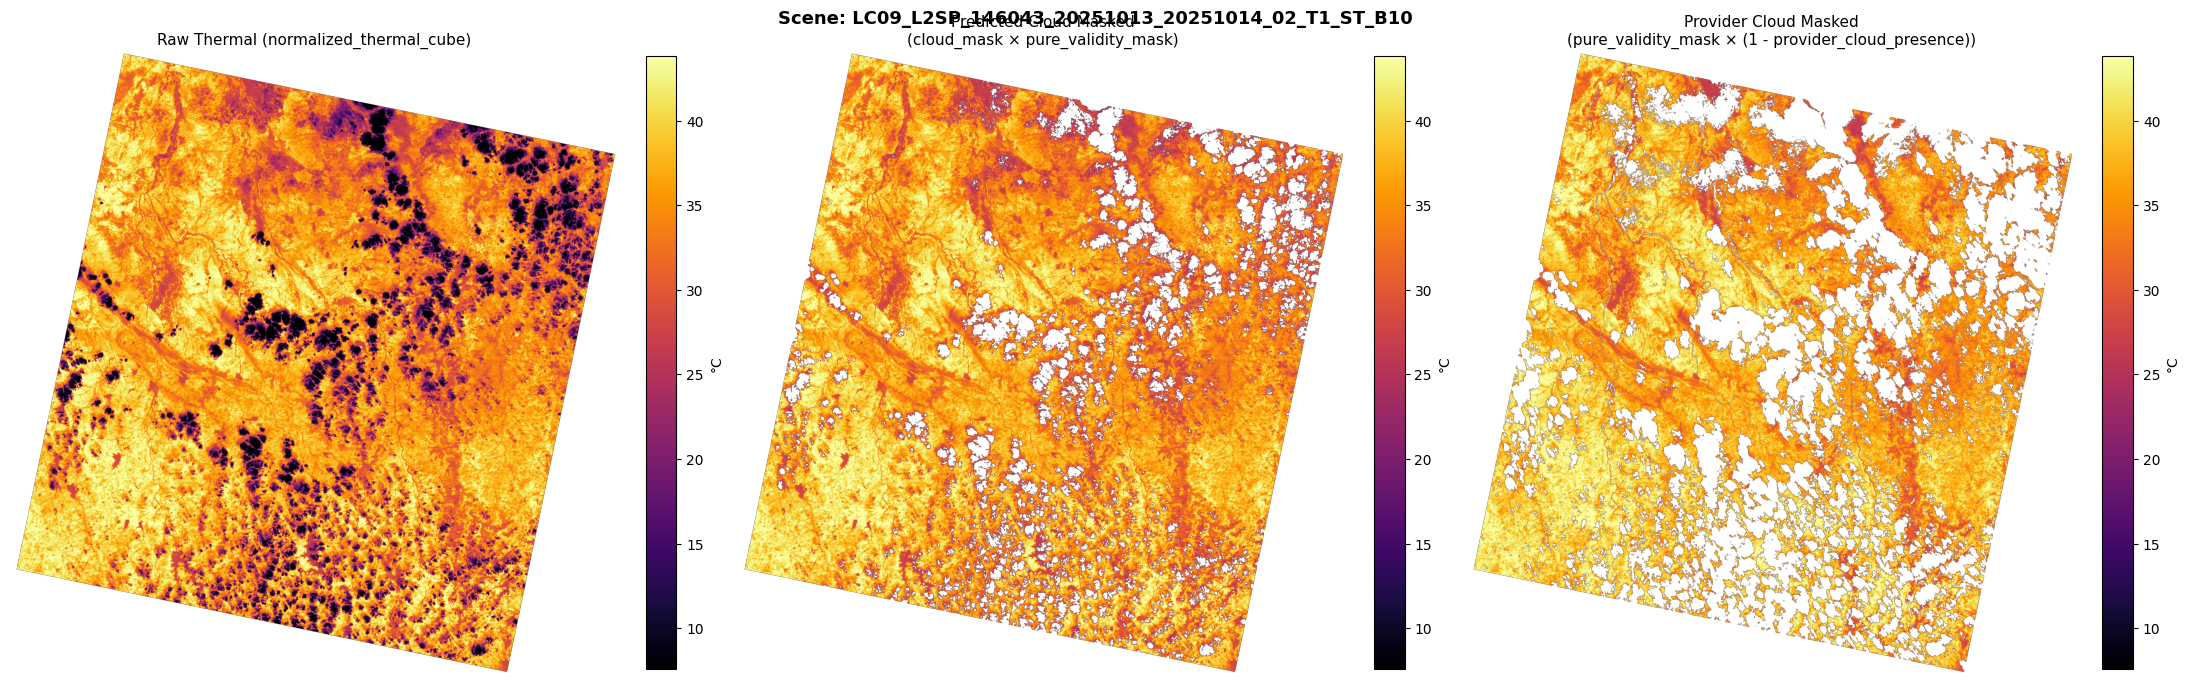

In [73]:
# Compute display range from the raw valid pixels
valid_temps = thermal_2d[vendable.pure_validity_mask[0].astype(bool)]
t_vmin = np.percentile(valid_temps, 2)
t_vmax = np.percentile(valid_temps, 98)

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# (a) Raw thermal
raw_display = thermal_2d.copy()
raw_display[~vendable.pure_validity_mask[0].astype(bool)] = np.nan
im0 = axes[0].imshow(raw_display, cmap="inferno", vmin=t_vmin, vmax=t_vmax)
axes[0].set_title("Raw Thermal (normalized_thermal_cube)", fontsize=11)
axes[0].axis("off")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label="°C")

# (b) Predicted cloud masked thermal
pred_display = thermal_2d.copy()
pred_display[~predicted_2d] = np.nan
im1 = axes[1].imshow(pred_display, cmap="inferno", vmin=t_vmin, vmax=t_vmax)
axes[1].set_title("Predicted Cloud Masked\n(cloud_mask × pure_validity_mask)", fontsize=11)
axes[1].axis("off")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label="°C")

# (c) Provider cloud masked thermal
prov_display = thermal_2d.copy()
prov_display[~provider_2d] = np.nan
im2 = axes[2].imshow(prov_display, cmap="inferno", vmin=t_vmin, vmax=t_vmax)
axes[2].set_title("Provider Cloud Masked\n(pure_validity_mask × (1 - provider_cloud_presence))", fontsize=11)
axes[2].axis("off")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04, label="°C")

fig.suptitle(f"Scene: {builder.stac_item.id}", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

## 5. Panel 2 — GRX anomaly scores under each mask

In [74]:
# GRX with predicted mask
detector_pred = ThermalGRXDetector(vendable)
detector_pred.fit()
scores_predicted = detector_pred.detect(cube, predicted_mask)
print(f"Predicted mask GRX: {np.isfinite(scores_predicted).sum():,} scored pixels")

# GRX with provider mask
detector_prov = ThermalGRXDetector(vendable)
detector_prov.fit()
scores_provider = detector_prov.detect(cube, provider_mask)
print(f"Provider mask GRX:  {np.isfinite(scores_provider).sum():,} scored pixels")

Predicted mask GRX: 35,864,861 scored pixels
Provider mask GRX:  26,914,649 scored pixels


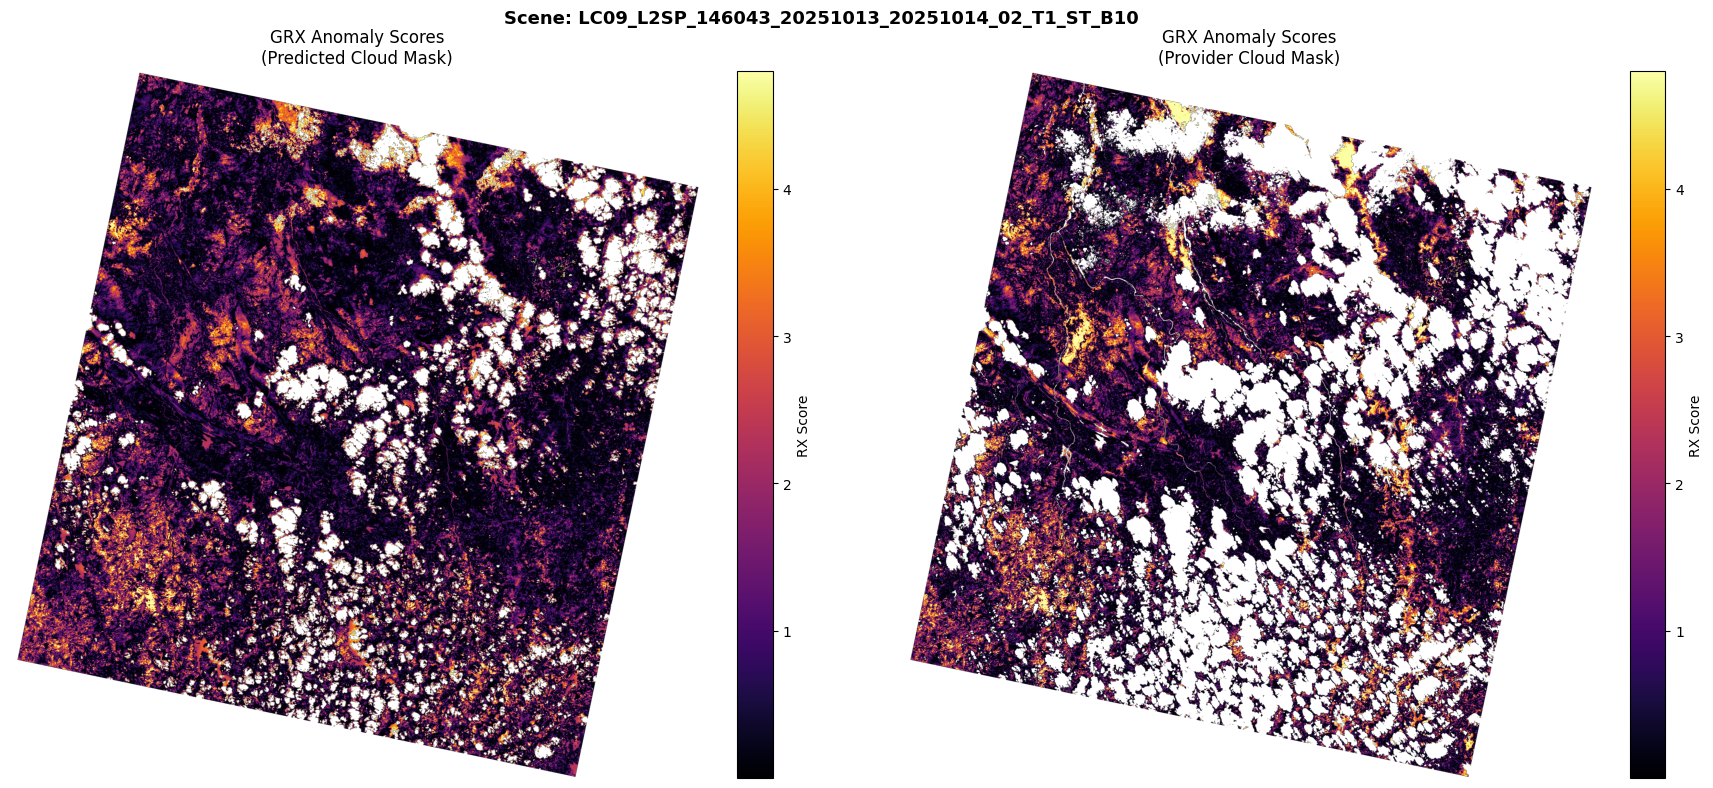

In [75]:
# Compute a shared color range across both score maps for fair comparison
all_valid_scores = np.concatenate([
    scores_predicted[predicted_2d & np.isfinite(scores_predicted)],
    scores_provider[provider_2d & np.isfinite(scores_provider)],
])
s_vmin = np.percentile(all_valid_scores, 2)
s_vmax = np.percentile(all_valid_scores, 98)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# (a) GRX scores — predicted mask
disp_pred = scores_predicted.copy()
disp_pred[~np.isfinite(disp_pred)] = np.nan
im0 = axes[0].imshow(disp_pred, cmap="inferno", vmin=s_vmin, vmax=s_vmax)
axes[0].set_title("GRX Anomaly Scores\n(Predicted Cloud Mask)", fontsize=12)
axes[0].axis("off")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label="RX Score")

# (b) GRX scores — provider mask
disp_prov = scores_provider.copy()
disp_prov[~np.isfinite(disp_prov)] = np.nan
im1 = axes[1].imshow(disp_prov, cmap="inferno", vmin=s_vmin, vmax=s_vmax)
axes[1].set_title("GRX Anomaly Scores\n(Provider Cloud Mask)", fontsize=12)
axes[1].axis("off")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label="RX Score")

fig.suptitle(f"Scene: {builder.stac_item.id}", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

## 6. Score distribution comparison

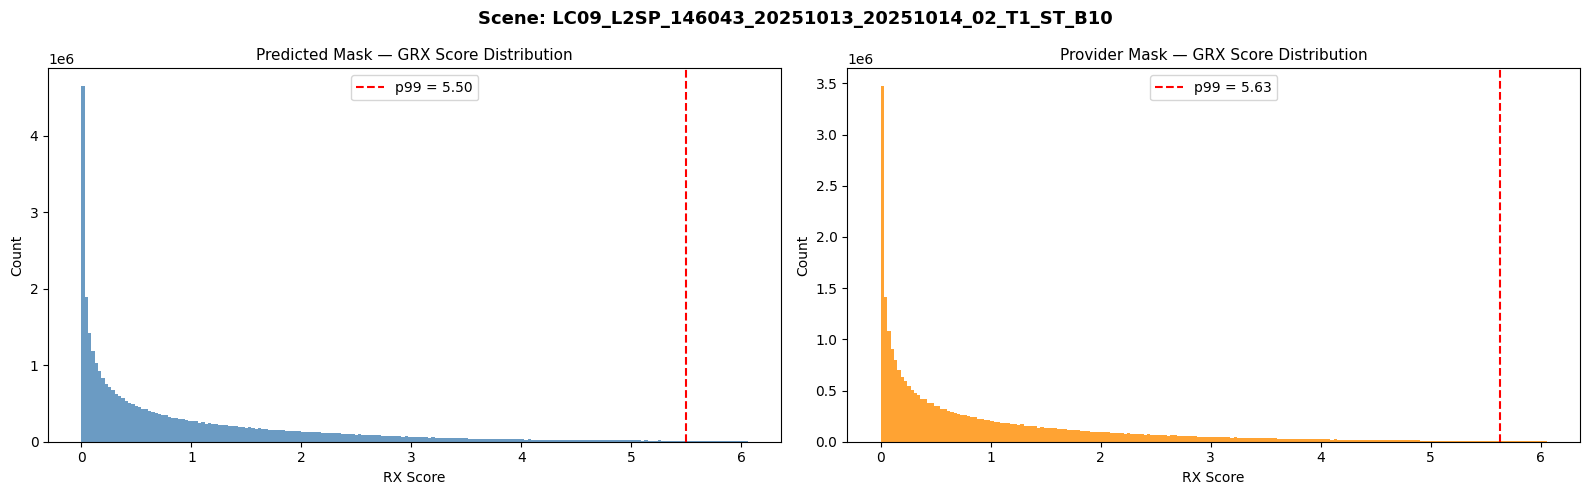


Predicted mask — median: 0.5199, p99: 5.4954, max: 38.0905
Provider mask  — median: 0.5074, p99: 5.6341, max: 92.7983


In [76]:
pred_valid = scores_predicted[predicted_2d & np.isfinite(scores_predicted)]
prov_valid = scores_provider[provider_2d & np.isfinite(scores_provider)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Clip at p99.5 for readable histograms
clip_val = np.percentile(all_valid_scores, 99.5)

axes[0].hist(pred_valid[pred_valid <= clip_val], bins=200, color="steelblue", alpha=0.8)
axes[0].axvline(np.percentile(pred_valid, 99), color="red", ls="--", label=f"p99 = {np.percentile(pred_valid, 99):.2f}")
axes[0].set_title("Predicted Mask — GRX Score Distribution", fontsize=11)
axes[0].set_xlabel("RX Score")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].hist(prov_valid[prov_valid <= clip_val], bins=200, color="darkorange", alpha=0.8)
axes[1].axvline(np.percentile(prov_valid, 99), color="red", ls="--", label=f"p99 = {np.percentile(prov_valid, 99):.2f}")
axes[1].set_title("Provider Mask — GRX Score Distribution", fontsize=11)
axes[1].set_xlabel("RX Score")
axes[1].set_ylabel("Count")
axes[1].legend()

fig.suptitle(f"Scene: {builder.stac_item.id}", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

print(f"\nPredicted mask — median: {np.median(pred_valid):.4f}, p99: {np.percentile(pred_valid, 99):.4f}, max: {pred_valid.max():.4f}")
print(f"Provider mask  — median: {np.median(prov_valid):.4f}, p99: {np.percentile(prov_valid, 99):.4f}, max: {prov_valid.max():.4f}")

## 7. Cleanup

In [77]:
import shutil
shutil.rmtree(tmp_dir)
print(f"Cleaned up {tmp_dir}")

Cleaned up /var/folders/_5/16204pp15b5g4nzv_mhf6pg40000gn/T/tmp74g7q_bl
